In [1]:
import pandas as pd
import numpy as np


In [19]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("df.info")
print(df.info())
print("df.describe")
print(df.describe())
print("df.head")
print(df.head())

print(f"Före rengöring: {len(df)} rader")
print(f"Saknade värden:\n{df.isnull().sum()}")


df.info
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17

In [20]:
df["TotalCharges"] = (
    df["TotalCharges"]
    .str.replace(" ", "0", regex=False)
    .astype(float)
)

In [22]:
df.to_excel("output.xlsx")

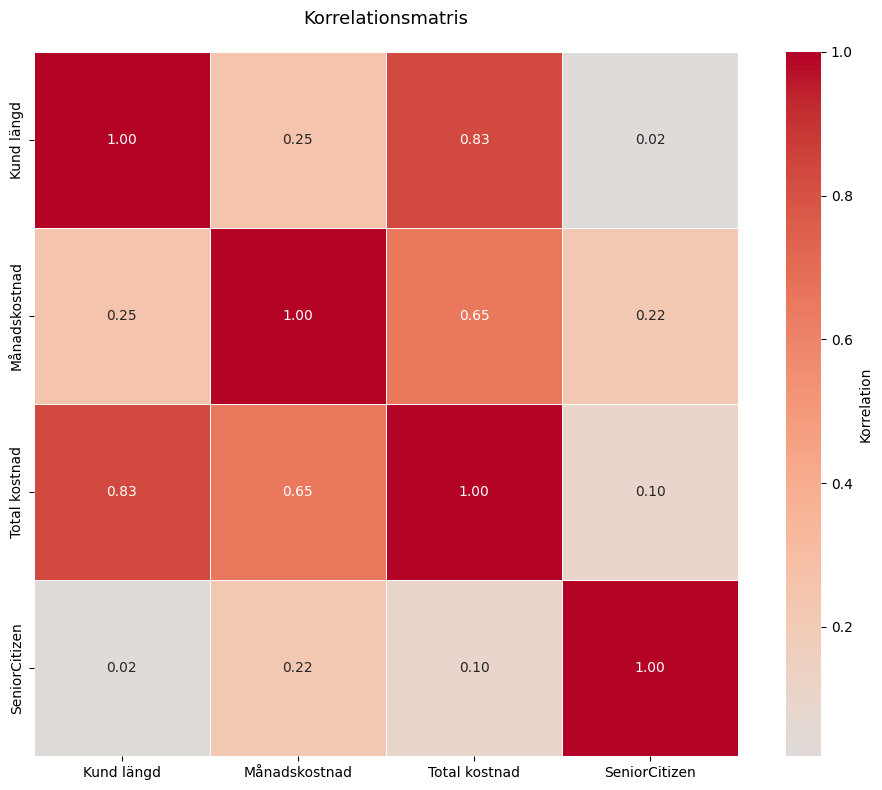

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Välj relevanta numeriska kolumner
cols_heatmap = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen'
]

# Beräkna korrelationsmatris
corr = df[cols_heatmap].corr().round(2)

# Svenska kolumnnamn
corr.columns = [
    'Kund längd',
    'Månadskostnad', 
    'Total kostnad',
    'SeniorCitizen'
]
corr.index = corr.columns

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Korrelation'}
)
plt.title('Korrelationsmatris', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

In [26]:
# 1. Kolla att det inte finns några konstigheter kvar
print(df['TotalCharges'].dtype)        # ska nu vara float64
print(df['TotalCharges'].isna().sum()) # ska vara 0
print(df['TotalCharges'].describe())

# 2. Sanity check: TotalCharges borde ungefär vara tenure * MonthlyCharges
df['expected'] = df['tenure'] * df['MonthlyCharges']
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'expected']].head(10)

float64
0
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


,tenure,MonthlyCharges,TotalCharges,expected
0,1,29.85,29.85,29.85
1,34,56.95,1889.50,1936.30
2,2,53.85,108.15,107.70
3,45,42.30,1840.75,1903.50
4,2,70.70,151.65,141.40
5,8,99.65,820.50,797.20
6,22,89.10,1949.40,1960.20
7,10,29.75,301.90,297.50
8,28,104.80,3046.05,2934.40
9,62,56.15,3487.95,3481.30


In [27]:
df = df.drop(columns=['expected'])

In [28]:
# Lista alla object-kolumner och deras unika värden
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')  # ID är inte en feature

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: 

C:\Users\ES7233\AppData\Local\Temp\ipykernel_40700\2627441640.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [29]:
# Gruppera kolumnerna
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    df[col] = df[col].replace('No internet service', 'No')

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Verifiera
for col in internet_cols + ['MultipleLines']:
    print(f"{col}: {df[col].unique()}")

OnlineSecurity: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
DeviceProtection: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [30]:
# Konvertera Churn till binära värden från No/Yes
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [31]:
# df = hela datasetet, behåller customerID för uppslagning, debugging, presentation
# y  = målvariabel
# X  = bara features som går in i modellen (utan ID och utan target)

y = df['Churn']
X = df.drop(columns=['customerID', 'Churn'])

print(f"X shape: {X.shape}")  # (7043, 19)
print(f"y shape: {y.shape}")  # (7043,)
print(f"df shape (orörd): {df.shape}")  # (7043, 21)

X shape: (7043, 19)
y shape: (7043,)
df shape (orörd): (7043, 21)


In [32]:
# Vi sparar originalet (utan dummies) – kan vara värt att ha kvar till sen!
X_orig = X.copy()

X = pd.get_dummies(X, drop_first=True, dtype=int)

print(f"X shape efter dummy: {X.shape}")
print(X.dtypes.value_counts())

X shape efter dummy: (7043, 23)
int64      21
float64     2
Name: count, dtype: int64


In [33]:
# Kolla hur det blev med get_dummies
print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0            1               0                 0                  0   
1            0               0                 1                  0   
2            0               0                 1                  0   
3            0               0                 0                  0   
4            0               0                 1                  0   

   InternetService_Fiber optic  ...  DeviceProtection_Yes  TechSupport_Yes  \
0                            0  ...                     0           

In [36]:
# Nu delar vi på datasetet i tränings- och testdata med en 70/30 split, då vi har relativt mycket data
# stratify=y tvingar train_test_split att bevara proportionerna av målvariabeln i både train och test.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print()
print("Andel churn i train:", y_train.mean().round(3))
print("Andel churn i test: ", y_test.mean().round(3))

X_train: (4930, 23), y_train: (4930,)
X_test:  (2113, 23), y_test:  (2113,)

Andel churn i train: 0.265
Andel churn i test:  0.265


C:\Users\ES7233\AppData\Local\Temp\ipykernel_40700\1950109889.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['steelblue', 'coral'])
C:\Users\ES7233\AppData\Local\Temp\ipykernel_40700\1950109889.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No (kvar)', 'Yes (uppsagt)'])


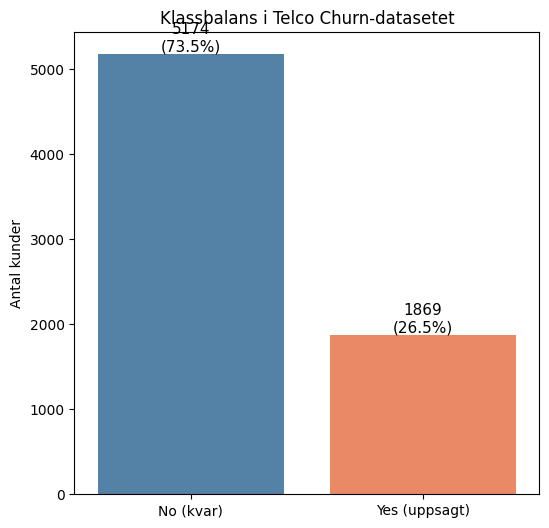

In [41]:
# Gör en countplot för att se obalans i datat

plt.figure(figsize=(6, 6))
ax = sns.countplot(x='Churn', data=df, palette=['steelblue', 'coral'])

# Sätt tydliga etiketter (0/1 är inte lika läsbart som No/Yes)
ax.set_xticklabels(['No (kvar)', 'Yes (uppsagt)'])
ax.set_xlabel('')
ax.set_ylabel('Antal kunder')
ax.set_title('Klassbalans i Telco Churn-datasetet')

# Lägg på antal + procent ovanför staplarna
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f'{count}\n({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.show()

In [43]:
# Skalning
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print("Efter skalning (train):")
print(X_train_scaled[numeric_cols].describe().round(2))

Efter skalning (train):
        tenure  MonthlyCharges  TotalCharges  SeniorCitizen
count  4930.00         4930.00       4930.00        4930.00
mean      0.00            0.00         -0.00          -0.00
std       1.00            1.00          1.00           1.00
min      -1.32           -1.54         -1.00          -0.44
25%      -0.95           -0.97         -0.83          -0.44
50%      -0.14            0.19         -0.40          -0.44
75%       0.95            0.83          0.68          -0.44
max       1.60            1.78          2.78           2.28


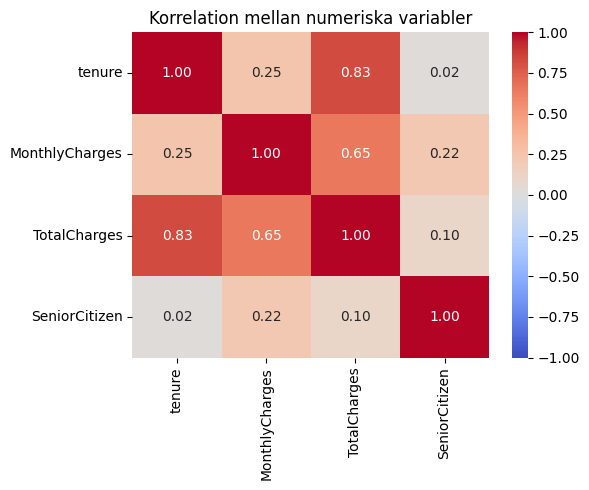

                tenure  MonthlyCharges  TotalCharges  SeniorCitizen
tenure            1.00            0.25          0.83           0.02
MonthlyCharges    0.25            1.00          0.65           0.22
TotalCharges      0.83            0.65          1.00           0.10
SeniorCitizen     0.02            0.22          0.10           1.00


In [44]:
# A: Numeriska mot varandra (multikollinearitet)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr_num = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, fmt='.2f')
plt.title('Korrelation mellan numeriska variabler')
plt.tight_layout()
plt.show()

print(corr_num.round(2))


# Vi ser att TotalCharges korrelerar ofantligt högt med hur länge man har varit kund, vilket är naturligt. 
# Här har vi multikollinearitet som vi eventuellt bör hantera genom att droppa TotalCharges.

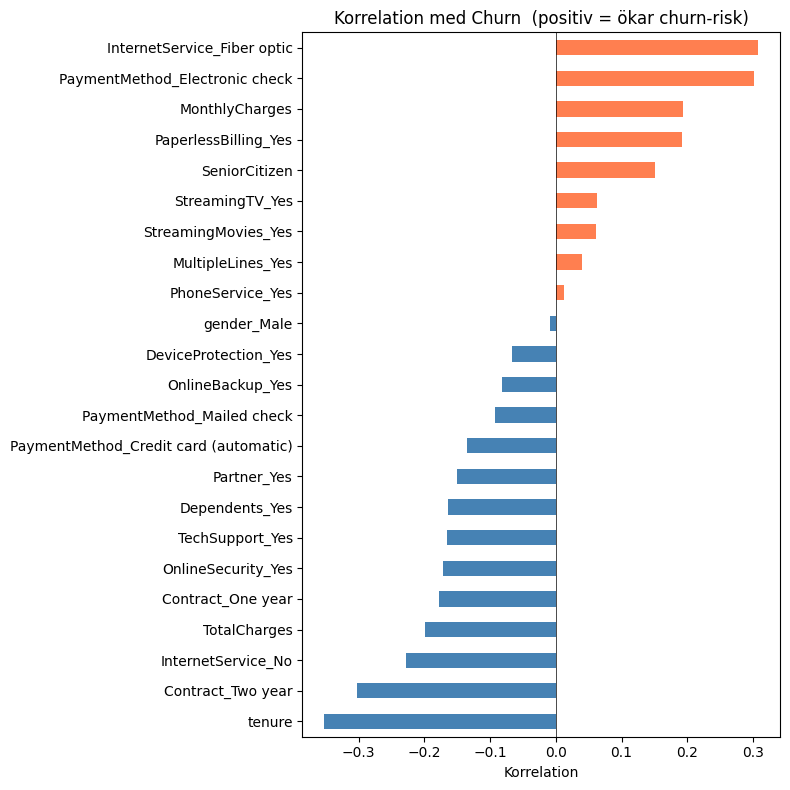

tenure                                  -0.352
Contract_Two year                       -0.302
InternetService_No                      -0.228
TotalCharges                            -0.198
Contract_One year                       -0.178
OnlineSecurity_Yes                      -0.171
TechSupport_Yes                         -0.165
Dependents_Yes                          -0.164
Partner_Yes                             -0.150
PaymentMethod_Credit card (automatic)   -0.134
PaymentMethod_Mailed check              -0.092
OnlineBackup_Yes                        -0.082
DeviceProtection_Yes                    -0.066
gender_Male                             -0.009
PhoneService_Yes                         0.012
MultipleLines_Yes                        0.040
StreamingMovies_Yes                      0.061
StreamingTV_Yes                          0.063
SeniorCitizen                            0.151
PaperlessBilling_Yes                     0.192
MonthlyCharges                           0.193
PaymentMethod

In [45]:
# B: Allt mot Churn (vad driver churn?)
df_corr = X.copy()
df_corr['Churn'] = y
churn_corr = df_corr.corr()['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(8, 8))
colors = ['steelblue' if v < 0 else 'coral' for v in churn_corr]
churn_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Korrelation med Churn  (positiv = ökar churn-risk)')
plt.xlabel('Korrelation')
plt.tight_layout()
plt.show()

print(churn_corr.round(3))

In [ ]:
#  Mycket intressant! Fiberkunder verkar leda ligan i uppsagda kontrakt.  De som betalar med elektronisk check och de med hög månadskostnad har en tendens att säga upp kontraktet! Intressant.
# De som har varit kunder länge har en tendens att fortsätta vara kunder.

In [46]:
# Logistisk regression med statsmodels

import statsmodels.api as sm

# Lägg till intercept manuellt (säkrare än sm.add_constant)
X_train_sm = X_train_scaled.copy()
X_train_sm.insert(0, 'const', 1.0)

# Fitta logistisk regression
model = sm.Logit(y_train, X_train_sm)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.412899
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 4930
Model:                          Logit   Df Residuals:                     4906
Method:                           MLE   Df Model:                           23
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.2863
Time:                        15:23:57   Log-Likelihood:                -2035.6
converged:                       True   LL-Null:                       -2852.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -3.9380      

In [ ]:
# Modellen som helhet är statistisk signifikant och Pseudo R-square på 0,29 kan anses som helt OK! Antal observationer 4930 vilket är hela träningssetet.

Confusion Matrix:
[[1395  157]
 [ 248  313]]

              precision    recall  f1-score   support

    Kvar (0)       0.85      0.90      0.87      1552
   Churn (1)       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



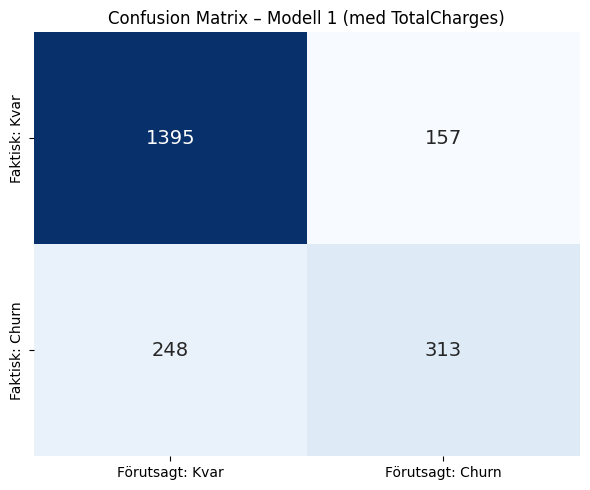

In [48]:
# Predicera på testdata
X_test_sm = X_test_scaled.copy()
X_test_sm.insert(0, 'const', 1.0)

y_pred_proba = result.predict(X_test_sm)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test, y_pred, target_names=['Kvar (0)', 'Churn (1)']))

# Visualisera
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Förutsagt: Kvar', 'Förutsagt: Churn'],
            yticklabels=['Faktisk: Kvar', 'Faktisk: Churn'],
            cbar=False, ax=ax, annot_kws={'size': 14})
ax.set_title('Confusion Matrix – Modell 1 (med TotalCharges)')
plt.tight_layout()
plt.show()

C:\Users\ES7233\AppData\Local\Temp\ipykernel_40700\3038308230.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Churn', y='TotalCharges', ax=axes[0],
C:\Users\ES7233\AppData\Local\Temp\ipykernel_40700\3038308230.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Kvar', 'Churn'])


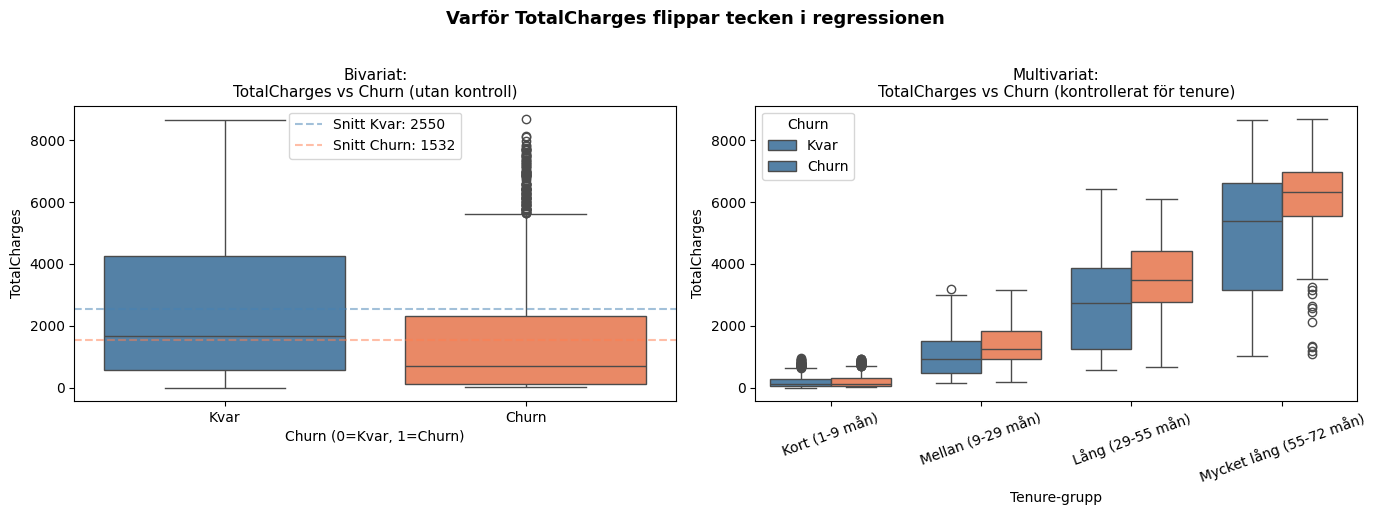

In [47]:
# Skapa fyra kvartiler av tenure för att kunna gruppera
df_viz = df.copy()
df_viz['tenure_grupp'] = pd.qcut(df_viz['tenure'].clip(lower=1),
                                  q=4,
                                  labels=['Kort (1-9 mån)',
                                          'Mellan (9-29 mån)',
                                          'Lång (29-55 mån)',
                                          'Mycket lång (55-72 mån)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Plot 1: Bivariat ===
sns.boxplot(data=df_viz, x='Churn', y='TotalCharges', ax=axes[0],
            palette=['steelblue', 'coral'])
axes[0].set_title('Bivariat:\nTotalCharges vs Churn (utan kontroll)',
                  fontsize=11)
axes[0].set_xlabel('Churn (0=Kvar, 1=Churn)')
axes[0].set_xticklabels(['Kvar', 'Churn'])

# Beräkna och visa medelvärden
means = df_viz.groupby('Churn')['TotalCharges'].mean()
axes[0].axhline(means[0], color='steelblue', linestyle='--', alpha=0.5,
                label=f'Snitt Kvar: {means[0]:.0f}')
axes[0].axhline(means[1], color='coral', linestyle='--', alpha=0.5,
                label=f'Snitt Churn: {means[1]:.0f}')
axes[0].legend()

# === Plot 2: Multivariat – inom samma tenure-grupp ===
sns.boxplot(data=df_viz, x='tenure_grupp', y='TotalCharges',
            hue='Churn', ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('Multivariat:\nTotalCharges vs Churn (kontrollerat för tenure)',
                  fontsize=11)
axes[1].set_xlabel('Tenure-grupp')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Churn', labels=['Kvar', 'Churn'])

plt.suptitle('Varför TotalCharges flippar tecken i regressionen',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Korrelationen mellan TotalCharges och Churn har varit en illusion, det är tenure som varit drivande, dvs hur länge man varit kund.
# Med det så beslutar vi oss för att droppa TotalCHarges-variableln.

In [49]:
# Vi sparar metrikerna från denna modell och efter det gör vi om testet med TotalCharges droppat!

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

resultat = {
    'Modell 1 (med TotalCharges, tröskel 0.5)': {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_proba),
    }
}

print(pd.DataFrame(resultat).round(3))

           Modell 1 (med TotalCharges, tröskel 0.5)
Accuracy                                      0.808
Precision                                     0.666
Recall                                        0.558
F1                                            0.607
ROC-AUC                                       0.845


In [58]:
# Logistisk regression igen men droppa TotalCharges

# Lägg till intercept manuellt (säkrare än sm.add_constant)
X_train_sm2 = X_train_scaled.copy()
X_train_sm2 = X_train_sm2.drop(columns=['TotalCharges'])
X_train_sm2.insert(0, 'const', 1.0)

# Fitta logistisk regression
model2 = sm.Logit(y_train, X_train_sm2)
result2 = model2.fit()

print(result2.summary())


Optimization terminated successfully.
         Current function value: 0.414384
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 4930
Model:                          Logit   Df Residuals:                     4907
Method:                           MLE   Df Model:                           22
Date:                Tue, 05 May 2026   Pseudo R-squ.:                  0.2837
Time:                        15:52:54   Log-Likelihood:                -2042.9
converged:                       True   LL-Null:                       -2852.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -3.9877      

In [61]:
# Ny confusion matrix

# Modell 2-prediktion
X_test_sm2 = X_test_scaled.copy()
X_test_sm2 = X_test_sm2.drop(columns=['TotalCharges'])
X_test_sm2.insert(0, 'const', 1.0)

y_pred_proba2 = result2.predict(X_test_sm2)
y_pred2 = (y_pred_proba2 >= 0.5).astype(int)

# Confusion matrix
cm2 = confusion_matrix(y_test, y_pred2)
print("Modell 2 – Confusion Matrix:")
print(cm2)
print()
print(classification_report(y_test, y_pred2, target_names=['Kvar (0)', 'Churn (1)']))

# Spara resultat för jämförelse
resultat['Modell 2 (utan TotalCharges, tröskel 0.5)'] = {
    'Accuracy':  accuracy_score(y_test, y_pred2),
    'Precision': precision_score(y_test, y_pred2),
    'Recall':    recall_score(y_test, y_pred2),
    'F1':        f1_score(y_test, y_pred2),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba2),
}

print("\nJämförelse:")
print(pd.DataFrame(resultat).round(3))

Modell 2 – Confusion Matrix:
[[1387  165]
 [ 257  304]]

              precision    recall  f1-score   support

    Kvar (0)       0.84      0.89      0.87      1552
   Churn (1)       0.65      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.75      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113


Jämförelse:
           Modell 1 (med TotalCharges, tröskel 0.5)  \
Accuracy                                      0.808   
Precision                                     0.666   
Recall                                        0.558   
F1                                            0.607   
ROC-AUC                                       0.845   

           Modell 2 (utan TotalCharges, tröskel 0.5)  
Accuracy                                       0.800  
Precision                                      0.648  
Recall                                         0.542  
F1                                             0.590

In [ ]:
# Inget blev bättre med droppad TotalCharges!
# Här verkar vi ha en klassiskt konflikt mellan ML och statistiklära. 
# Statistisk modellering: "Modellen ska berätta något om verkligheten. Tolkningsbara koefficienter är viktigare."
# ML: "Modellen ska prediktera bra. Punkt. Tolkning är sekundärt."
# Då detta är en kurs i ML bestämmer vi oss för att fortsätta med TotalCharges inkluderat

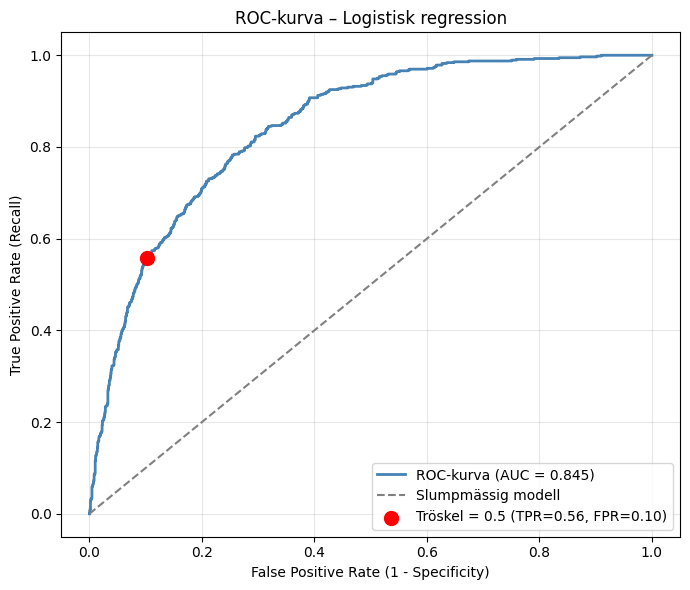

In [62]:
# Vi provar att tröskeloptimera för att se om vi kan förbättra prestandan!

from sklearn.metrics import roc_curve, roc_auc_score

# Räkna ut ROC-kurvan
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plotta
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC-kurva (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Slumpmässig modell')

# Markera tröskel 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[idx_05], tpr[idx_05], color='red', s=100, zorder=5,
            label=f'Tröskel = 0.5 (TPR={tpr[idx_05]:.2f}, FPR={fpr[idx_05]:.2f})')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-kurva – Logistisk regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
# Ny confusion matrix vid den optimala tröskeln

# Youden's J = TPR - FPR (samma som sensitivitet + specificitet - 1)
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal tröskel (Youden's J): {optimal_threshold:.3f}")
print(f"Vid den tröskeln: TPR = {tpr[optimal_idx]:.3f}, FPR = {fpr[optimal_idx]:.3f}")
print(f"Youden's J vid 0.5:    {J[idx_05]:.3f}")
print(f"Youden's J vid optimal: {J[optimal_idx]:.3f}")

# Predicera om med den nya tröskeln
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

cm_opt = confusion_matrix(y_test, y_pred_optimal)
print(f"\nConfusion Matrix vid tröskel = {optimal_threshold:.3f}:")
print(cm_opt)
print()
print(classification_report(y_test, y_pred_optimal, target_names=['Kvar (0)', 'Churn (1)']))

# Lägg till i jämförelsen
resultat[f'Modell 1 (Youden tröskel ≈ {optimal_threshold:.2f})'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_optimal),
    'Precision': precision_score(y_test, y_pred_optimal),
    'Recall':    recall_score(y_test, y_pred_optimal),
    'F1':        f1_score(y_test, y_pred_optimal),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba),
}

print("\nJämförelse:")
print(pd.DataFrame(resultat).round(3))

Optimal tröskel (Youden's J): 0.246
Vid den tröskeln: TPR = 0.824, FPR = 0.295
Youden's J vid 0.5:    0.456
Youden's J vid optimal: 0.528

Confusion Matrix vid tröskel = 0.246:
[[1094  458]
 [  99  462]]

              precision    recall  f1-score   support

    Kvar (0)       0.92      0.70      0.80      1552
   Churn (1)       0.50      0.82      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.81      0.74      0.75      2113


Jämförelse:
           Modell 1 (med TotalCharges, tröskel 0.5)  \
Accuracy                                      0.808   
Precision                                     0.666   
Recall                                        0.558   
F1                                            0.607   
ROC-AUC                                       0.845   

           Modell 2 (utan TotalCharges, tröskel 0.5)  \
Accuracy                                       0.800   
Precision   

In [ ]:
# Confusion matrix modell 1:
# Confusion Matrix:
# [[1395  157]
# [ 248  313]]
# Med den optimala tröskeln enligt Youden's J så identifierar vi 149 fler kunder som riskerar att säga upp sig, 
# dock med en kostnad att vi felaktigt förutser att 301 fler kunder ska lämna oss som egentligen hade stannat! (Trade off)

In [ ]:
# Logistisk regression END



# KNN START

In [66]:
from sklearn.neighbors import KNeighborsClassifier

# Fitta med default k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Prediktera
y_pred_knn = knn.predict(X_test_scaled)
y_pred_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]  # sannolikhet för klass 1

# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(f"KNN (k=5) – Confusion Matrix:")
print(cm_knn)
print()
print(classification_report(y_test, y_pred_knn, target_names=['Kvar (0)', 'Churn (1)']))

KNN (k=5) – Confusion Matrix:
[[1309  243]
 [ 257  304]]

              precision    recall  f1-score   support

    Kvar (0)       0.84      0.84      0.84      1552
   Churn (1)       0.56      0.54      0.55       561

    accuracy                           0.76      2113
   macro avg       0.70      0.69      0.69      2113
weighted avg       0.76      0.76      0.76      2113



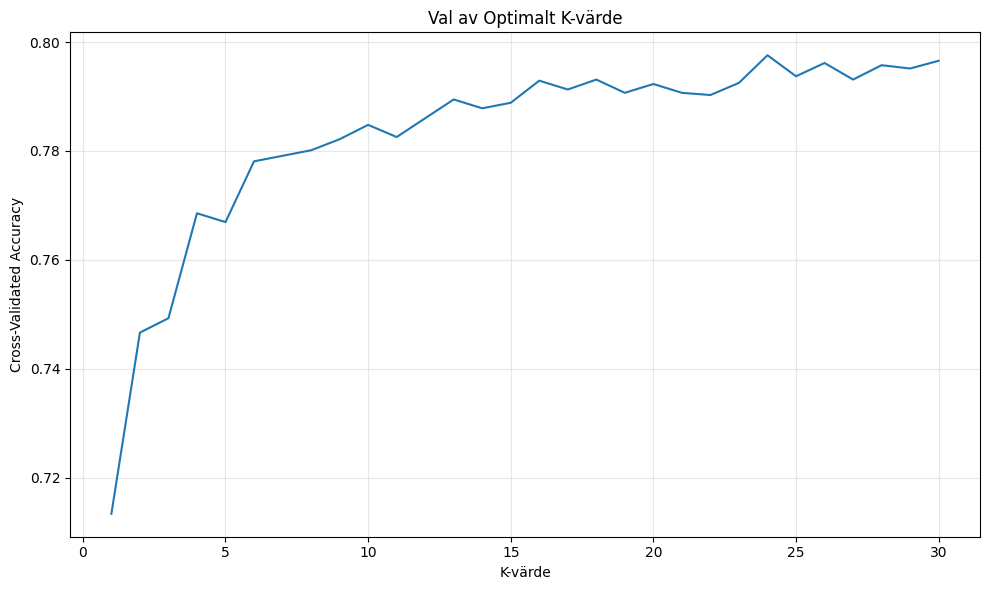

In [68]:
# Som väntat är resultatet sämre än vid den logistiska regressionen, men vi har inte optimerat k-värdet än! Vi anvönder en plot för att hitta det optimala värdet.

from sklearn.model_selection import cross_val_score

# Testa olika k-värden och se hur det påverkar modellens prestanda
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# Plotta resultaten
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores)
plt.xlabel('K-värde')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Val av Optimalt K-värde')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# Runt 20 verkar vi ha en platpå där det inte händer så mycket mer. Provar att köra om med det!

from sklearn.neighbors import KNeighborsClassifier

# Fitta med k=20
knn2 = KNeighborsClassifier(n_neighbors=20)
knn2.fit(X_train_scaled, y_train)

# Prediktera
y_pred_knn_best = knn.predict(X_test_scaled)
y_pred_proba_knn_best = knn.predict_proba(X_test_scaled)[:, 1]  # sannolikhet för klass 1

# Confusion matrix
cm_knn2 = confusion_matrix(y_test, y_pred_knn)
print(f"KNN (k=20) – Confusion Matrix:")
print(cm_knn2)
print()
print(classification_report(y_test, y_pred_knn, target_names=['Kvar (0)', 'Churn (1)']))

resultat[f'KNN (k=20, tröskel 0.5)'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_knn_best),
    'Precision': precision_score(y_test, y_pred_knn_best),
    'Recall':    recall_score(y_test, y_pred_knn_best),
    'F1':        f1_score(y_test, y_pred_knn_best),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba_knn_best),
}

KNN (k=20) – Confusion Matrix:
[[1376  176]
 [ 253  308]]

              precision    recall  f1-score   support

    Kvar (0)       0.84      0.89      0.87      1552
   Churn (1)       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [75]:
# Att jämföra med vår logistiska regression
df_resultat = pd.DataFrame(resultat).T.round(3)
print(pd.DataFrame(resultat).round(3))

           Modell 1 (med TotalCharges, tröskel 0.5)  \
Accuracy                                      0.808   
Precision                                     0.666   
Recall                                        0.558   
F1                                            0.607   
ROC-AUC                                       0.845   

           Modell 2 (utan TotalCharges, tröskel 0.5)  \
Accuracy                                       0.800   
Precision                                      0.648   
Recall                                         0.542   
F1                                             0.590   
ROC-AUC                                        0.842   

           Modell 1 (Youden tröskel ≈ 0.25)  KNN (k=20, tröskel 0.5)  
Accuracy                              0.736                    0.797  
Precision                             0.502                    0.636  
Recall                                0.824                    0.549  
F1                                    0.624     

In [76]:
# KNN med optimal tröskel, Youden's J.

fpr_knn, tpr_knn, thresh_knn = roc_curve(y_test, y_pred_proba_knn_best)
J_knn = tpr_knn - fpr_knn
optimal_idx_knn = np.argmax(J_knn)
optimal_threshold_knn = thresh_knn[optimal_idx_knn]

print(f"KNN optimal tröskel (Youden's J): {optimal_threshold_knn:.3f}")

y_pred_knn_opt = (y_pred_proba_knn_best >= optimal_threshold_knn).astype(int)

print(f"\nKNN (k=20, tröskel {optimal_threshold_knn:.3f}):")
print(confusion_matrix(y_test, y_pred_knn_opt))
print(classification_report(y_test, y_pred_knn_opt, target_names=['Kvar', 'Churn']))

resultat[f'KNN (k=20, Youden ≈ {optimal_threshold_knn:.2f})'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_knn_opt),
    'Precision': precision_score(y_test, y_pred_knn_opt),
    'Recall':    recall_score(y_test, y_pred_knn_opt),
    'F1':        f1_score(y_test, y_pred_knn_opt),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba_knn_best),
}

print("\nSlutlig jämförelse:")
print(pd.DataFrame(resultat).T.round(3))

KNN optimal tröskel (Youden's J): 0.300

KNN (k=20, tröskel 0.300):
[[1043  509]
 [  99  462]]
              precision    recall  f1-score   support

        Kvar       0.91      0.67      0.77      1552
       Churn       0.48      0.82      0.60       561

    accuracy                           0.71      2113
   macro avg       0.69      0.75      0.69      2113
weighted avg       0.80      0.71      0.73      2113


Slutlig jämförelse:
                                           Accuracy  Precision  Recall     F1  \
Modell 1 (med TotalCharges, tröskel 0.5)      0.808      0.666   0.558  0.607   
Modell 2 (utan TotalCharges, tröskel 0.5)     0.800      0.648   0.542  0.590   
Modell 1 (Youden tröskel ≈ 0.25)              0.736      0.502   0.824  0.624   
KNN (k=20, tröskel 0.5)                       0.797      0.636   0.549  0.589   
KNN (k=20, Youden ≈ 0.30)                     0.712      0.476   0.824  0.603   

                                           ROC-AUC  
Modell 1 (med Tot

In [ ]:
# Vinnare är logistsk regression på alla kategorier! 

In [ ]:
# KNN END

# Survival analysis start!

In [77]:
# Hur många kunder har tenure = 0?
print(f"Kunder med tenure=0: {(df['tenure'] == 0).sum()}") # Helt nya kunder
print(f"Av dessa har churn=1: {((df['tenure'] == 0) & (df['Churn'] == 1)).sum()}") # Helt nya kunder som har avslutat

# Lifelines klarar inte tid = 0, vilket vi behöver åtgärda

Kunder med tenure=0: 11
Av dessa har churn=1: 0


In [78]:
# 11 rader i sammanhanget är försumbart, så vi kan filtrera bort dom

# Skapa survival-dataset
df_surv = df[df['tenure'] > 0].copy()
print(f"Survival dataset: {df_surv.shape}")  # ska vara (7032, 21)



Survival dataset: (7032, 21)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


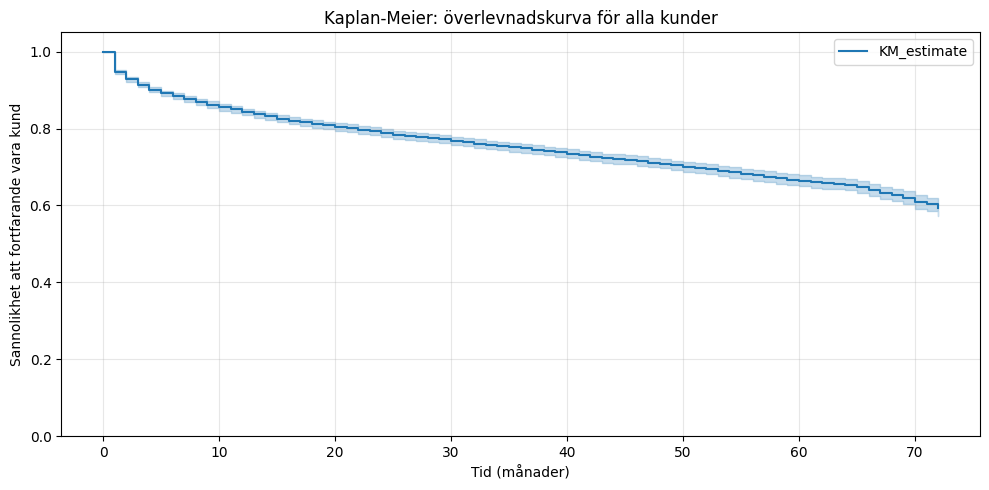


Median survival time: inf
Sannolikhet att vara kvar efter 12 mån: 0.843
Sannolikhet att vara kvar efter 24 mån: 0.789
Sannolikhet att vara kvar efter 60 mån: 0.664


In [81]:
# Kaplan-Meier-kurvan
%pip install lifelines
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations=df_surv['tenure'], event_observed=df_surv['Churn'])

# Plotta
fig, ax = plt.subplots(figsize=(10, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel('Tid (månader)')
ax.set_ylabel('Sannolikhet att fortfarande vara kund')
ax.set_title('Kaplan-Meier: överlevnadskurva för alla kunder')
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Skriv ut nyckelvärden
print(f"\nMedian survival time: {kmf.median_survival_time_}")
print(f"Sannolikhet att vara kvar efter 12 mån: {kmf.predict(12):.3f}")
print(f"Sannolikhet att vara kvar efter 24 mån: {kmf.predict(24):.3f}")
print(f"Sannolikhet att vara kvar efter 60 mån: {kmf.predict(60):.3f}")

In [ ]:
# Merparten av kunderna tenderar att vara kvar under studietidens längd. 66,4%! Av 100 kunder är 66 kvar. 
# Kurvan faller snabbt i början, vilket kan vara kunder som ångrar sig.
# När kurvan planat ut tenderar kunderna att stanna i högre grad!
# inf ennbär att mer än hälften är kvar efter studietidens slut!

In [82]:
# log-rank för att se resultatet statistiskt

from lifelines.statistics import multivariate_logrank_test

# Multivariate log-rank för 3 grupper samtidigt
results = multivariate_logrank_test(
    df_surv['tenure'],
    df_surv['Contract'],
    df_surv['Churn']
)
print(results.summary)
print(f"\np-värde: {results.p_value}")
print(f"Test-statistic: {results.test_statistic:.2f}")

   test_statistic    p  -log2(p)
0     2352.872538  0.0       inf

p-värde: 0.0
Test-statistic: 2352.87


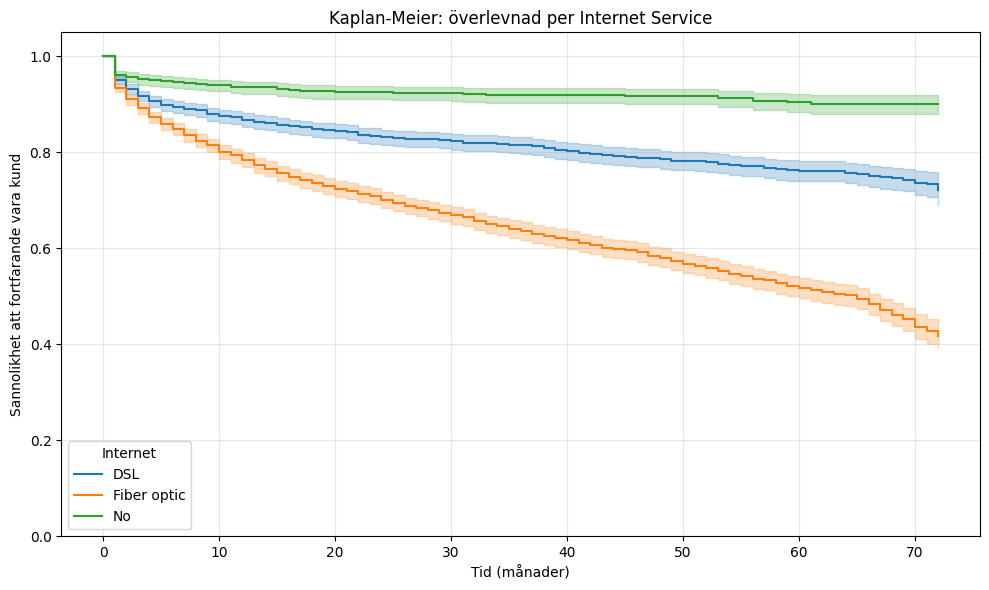


p-värde: 1.140893144871635e-113
Test-statistic: 520.12


In [83]:
fig, ax = plt.subplots(figsize=(10, 6))

for service_type in df_surv['InternetService'].unique():
    mask = df_surv['InternetService'] == service_type
    
    kmf = KaplanMeierFitter()
    kmf.fit(durations=df_surv.loc[mask, 'tenure'],
            event_observed=df_surv.loc[mask, 'Churn'],
            label=service_type)
    kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel('Tid (månader)')
ax.set_ylabel('Sannolikhet att fortfarande vara kund')
ax.set_title('Kaplan-Meier: överlevnad per Internet Service')
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)
ax.legend(title='Internet', loc='lower left')
plt.tight_layout()
plt.show()

# Log-rank
from lifelines.statistics import multivariate_logrank_test
results = multivariate_logrank_test(
    df_surv['tenure'],
    df_surv['InternetService'],
    df_surv['Churn']
)
print(f"\np-värde: {results.p_value}")
print(f"Test-statistic: {results.test_statistic:.2f}")

In [ ]:
# Kunder med fiberoptik tenderar avsluta sina abonemang i högre grad än övriga! Är dessa kunder missnöjda med servicen i högre grad?